<a href="https://colab.research.google.com/github/25730018/colab-notebooks/blob/main/UMAP%E3%82%B3%E3%83%9E%E3%83%B3%E3%83%894%E6%96%87%E5%AD%97.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install umap-learn

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import glob
from scipy import signal
import umap
import itertools
from mpl_toolkits.mplot3d import Axes3D
%matplotlib inline

# 元波形をそのままUMAP（計測部位別+連結）

In [ ]:
min=0
max=4000
N=max-min
sf=4000

name= ['ame', 'asa', 'ie', 'inu', 'kame', 'kasa', 'kumo', 'kutu', 'suna', 'usi', 'ohayou', 'tadaima', 'okaeri', 'oyasumi', 'ganbare', 'motiron', 'naruhodo', 'uresii', 'oisii', 'mosimosi']


#トレーニングデータ
path_trans='drive/MyDrive/suzuki_Data/suzuki/2024-10-31/emg2024-10-31-14-26-34/'
n_trans=50

target=[]
for i in range(len(name)):
    a=[i]*n_trans
    target=np.append(target,a)
target=target.reshape(len(target),1)

cou_trans=0
for name_num in range(len(name)):
    file_cou=0
    for file in glob.glob(path_trans+name[name_num]+'/*.csv'):
        cou_trans=cou_trans+1
        df=pd.read_csv(file,skiprows=13,header=None)
        data1=df[min:max][0]
        data2=df[min:max][1]
        data3=df[min:max][2]

        if(cou_trans==1):
            Sxx1_all=data1
            Sxx2_all=data2
            Sxx3_all=data3

            Sxx_all=np.concatenate([data1,data2,data3])
            print(cou_trans,file)
        else:
            Sxx1_all=np.vstack([Sxx1_all,data1])
            Sxx2_all=np.vstack([Sxx2_all,data2])
            Sxx3_all=np.vstack([Sxx3_all,data3])


            Sxx=np.concatenate([data1,data2,data3])
            Sxx_all=np.vstack([Sxx_all,Sxx])
            print(cou_trans,file)

        file_cou=file_cou+1
        if file_cou==n_trans:
            break

#--------------------------------------------------------------------------------------------
final1=Sxx1_all
final2=Sxx2_all
final3=Sxx3_all
final123=Sxx_all

# np.save(path_trans+".npy",final123)

1 drive/MyDrive/suzuki_Data/suzuki/2024-10-31/emg2024-10-31-14-26-34/1/1EMG2024-10-31-14-27-30.csv
2 drive/MyDrive/suzuki_Data/suzuki/2024-10-31/emg2024-10-31-14-26-34/1/1EMG2024-10-31-14-27-35.csv
3 drive/MyDrive/suzuki_Data/suzuki/2024-10-31/emg2024-10-31-14-26-34/1/1EMG2024-10-31-14-27-40.csv
4 drive/MyDrive/suzuki_Data/suzuki/2024-10-31/emg2024-10-31-14-26-34/1/1EMG2024-10-31-14-27-44.csv
5 drive/MyDrive/suzuki_Data/suzuki/2024-10-31/emg2024-10-31-14-26-34/1/1EMG2024-10-31-14-27-48.csv
6 drive/MyDrive/suzuki_Data/suzuki/2024-10-31/emg2024-10-31-14-26-34/1/1EMG2024-10-31-14-27-51.csv
7 drive/MyDrive/suzuki_Data/suzuki/2024-10-31/emg2024-10-31-14-26-34/1/1EMG2024-10-31-14-27-55.csv
8 drive/MyDrive/suzuki_Data/suzuki/2024-10-31/emg2024-10-31-14-26-34/1/1EMG2024-10-31-14-27-59.csv
9 drive/MyDrive/suzuki_Data/suzuki/2024-10-31/emg2024-10-31-14-26-34/1/1EMG2024-10-31-14-28-09.csv
10 drive/MyDrive/suzuki_Data/suzuki/2024-10-31/emg2024-10-31-14-26-34/1/1EMG2024-10-31-14-28-14.csv
11 drive/

In [ ]:
#UMAP設定--------------------------------------------------------------------------------------------
n_components=2
random_state=0
n_neighbors=15
min_dist=0.1
output_metric=['euclidean','cosine','manhattan']
output_metric=output_metric[0]
#グラフの設定--------------------------------------------------------------------------------------------
ma=['o']*10 #マーカーの種類
c = [
    '#1f77b4',  # 青
    '#ff7f0e',  # オレンジ
    '#2ca02c',  # 緑
    '#d62728',  # 赤
    '#9467bd',  # 紫
    '#8c564b',  # 茶色
    '#e377c2',  # ピンク
    '#7f7f7f',  # グレー
    '#bcbd22',  # イエロー
    '#17becf',   # シアン
]


#UMAP
trans1=umap.UMAP(n_components=n_components,random_state=random_state,n_neighbors=n_neighbors,min_dist=min_dist,output_metric=output_metric).fit(final1,y=target)
trans2=umap.UMAP(n_components=n_components,random_state=random_state,n_neighbors=n_neighbors,min_dist=min_dist,output_metric=output_metric).fit(final2,y=target)
trans3=umap.UMAP(n_components=n_components,random_state=random_state,n_neighbors=n_neighbors,min_dist=min_dist,output_metric=output_metric).fit(final3,y=target)
trans=umap.UMAP(n_components=n_components,random_state=random_state,n_neighbors=n_neighbors,min_dist=min_dist,output_metric=output_metric).fit(final123,y=target)

/usr/local/lib/python3.10/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.10/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.10/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.10/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


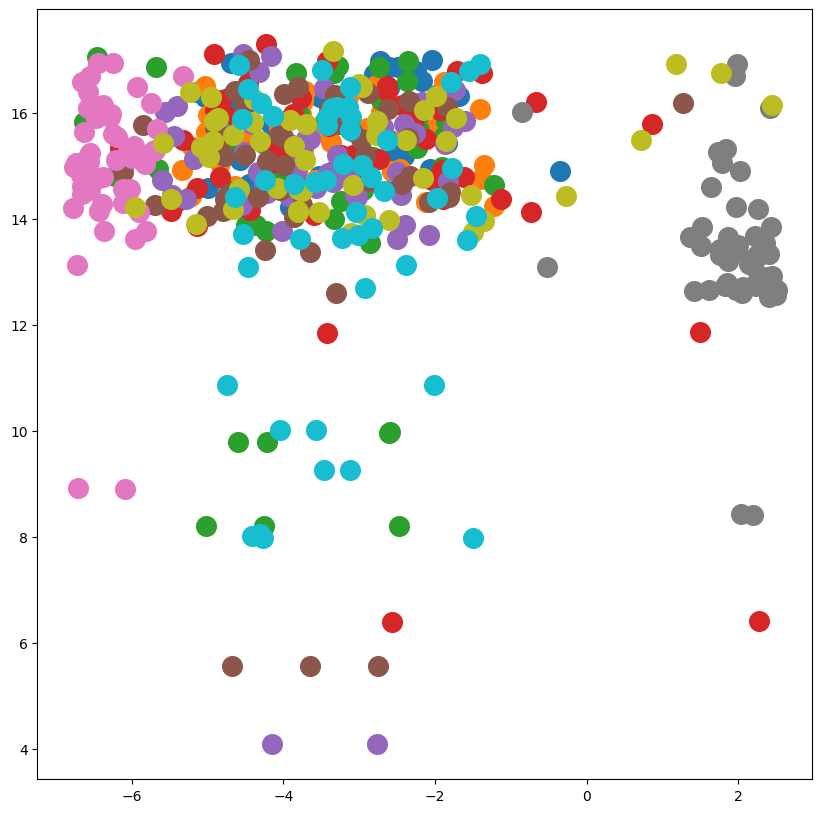

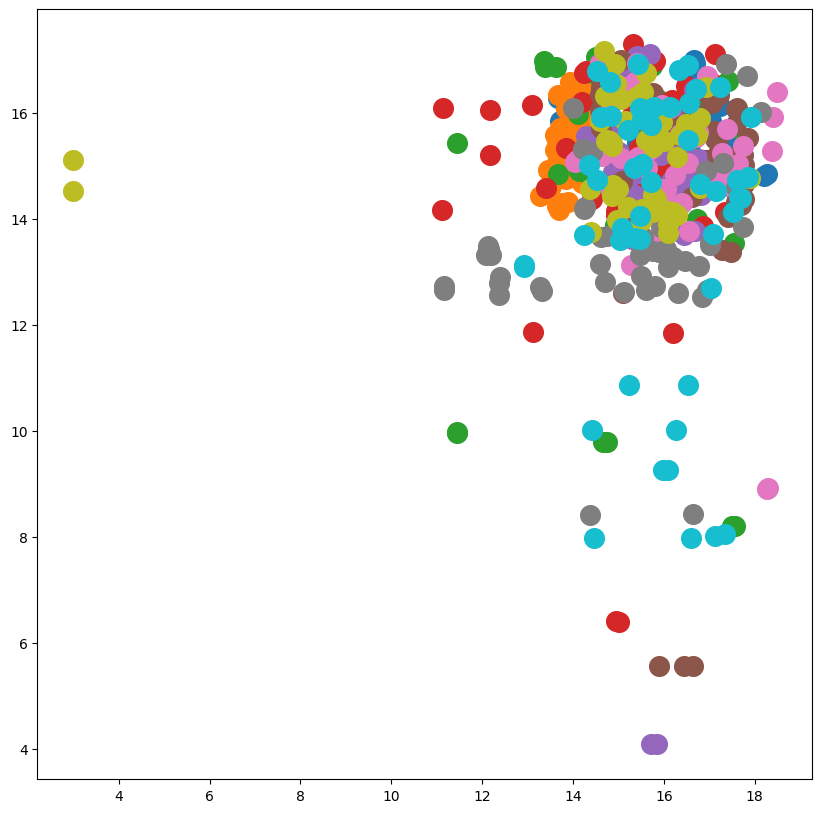

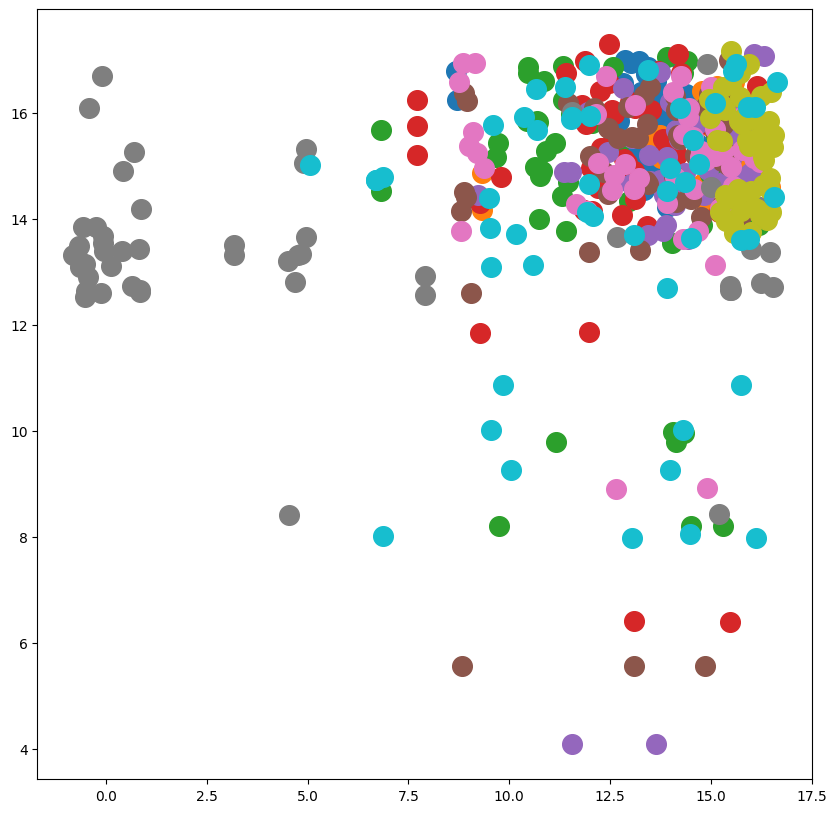

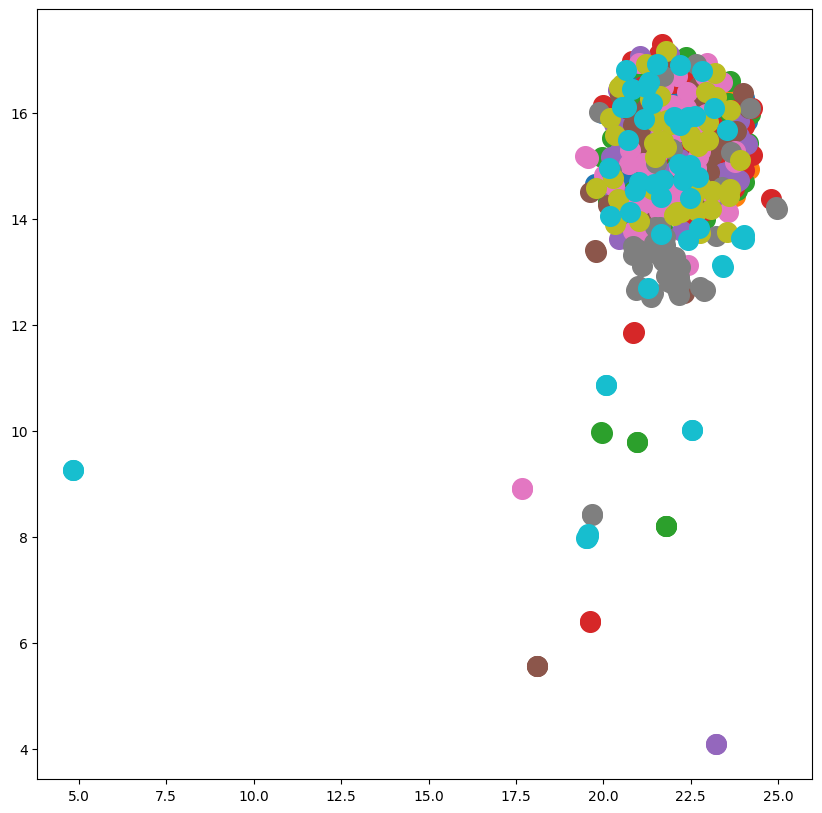

In [ ]:
# name= ['ありがとう', 'ごめんなさい', 'はじめまして', 'こんばんは', 'こんにちは', 'おはよう', 'おいしい', 'おねがいします', 'おつかれさま', 'さようなら']
name= ['1', '2', '3', '4', '5', '6', '7', '8', '9', '0']


plt.figure(figsize=[10,10])
for i in range(len(name)):
  plt.scatter(trans1.embedding_[n_trans*i:n_trans*(i+1),0],trans.embedding_[n_trans*i:n_trans*(i+1),1],c=c[i],s=200,marker=ma[i],label=name[i])
# plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0, fontsize=15,ncol=5)
# plt.title('UMAP(full-bond)'+' ch1~3'+'\n'+'STFT:  '+'nperseg='+str(nperseg)+'  '+'noverlap='+str(noverlap)+'  '+'Sn='+str(Sn)+'\n'+'UMAP:  '+'n_nei='+str(n_neighbors)+'  '+'min_dist='+str(min_dist),loc='left')
# plt.xlim(-5,25)
# plt.ylim(-5,25)
plt.show()
plt.clf()
plt.close()

plt.figure(figsize=[10,10])
for i in range(len(name)):
  plt.scatter(trans2.embedding_[n_trans*i:n_trans*(i+1),0],trans.embedding_[n_trans*i:n_trans*(i+1),1],c=c[i],s=200,marker=ma[i],label=name[i])
# plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0, fontsize=15)
#plt.title('UMAP(full-bond)'+' ch1~3'+'\n'+'STFT:  '+'nperseg='+str(nperseg)+'  '+'noverlap='+str(noverlap)+'  '+'Sn='+str(Sn)+'\n'+'UMAP:  '+'n_nei='+str(n_neighbors)+'  '+'min_dist='+str(min_dist),loc='left')
# plt.xlim(-5,25)
# plt.ylim(-5,25)
plt.show()
plt.clf()
plt.close()

plt.figure(figsize=[10,10])
for i in range(len(name)):
  plt.scatter(trans3.embedding_[n_trans*i:n_trans*(i+1),0],trans.embedding_[n_trans*i:n_trans*(i+1),1],c=c[i],s=200,marker=ma[i],label=name[i])
# plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0, fontsize=15)
#plt.title('UMAP(full-bond)'+' ch1~3'+'\n'+'STFT:  '+'nperseg='+str(nperseg)+'  '+'noverlap='+str(noverlap)+'  '+'Sn='+str(Sn)+'\n'+'UMAP:  '+'n_nei='+str(n_neighbors)+'  '+'min_dist='+str(min_dist),loc='left')
# plt.xlim(-5,25)
# plt.ylim(-5,25)
plt.show()
plt.clf()
plt.close()

plt.figure(figsize=[10,10])
for i in range(len(name)):
  plt.scatter(trans.embedding_[n_trans*i:n_trans*(i+1),0],trans.embedding_[n_trans*i:n_trans*(i+1),1],c=c[i],s=200,marker=ma[i],label=name[i])
# plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0, fontsize=15)
#plt.title('UMAP(full-bond)'+' ch1~3'+'\n'+'STFT:  '+'nperseg='+str(nperseg)+'  '+'noverlap='+str(noverlap)+'  '+'Sn='+str(Sn)+'\n'+'UMAP:  '+'n_nei='+str(n_neighbors)+'  '+'min_dist='+str(min_dist),loc='left')
# plt.xlim(-5,25)
# plt.ylim(-5,25)
plt.show()
plt.clf()
plt.close()

# STFT+UMAP（計測部位別+連結）

In [ ]:
min=0
max=6000
N=max-min
sf=4000

nperseg=256
noverlap=128
Sn=60

name= ['ame', 'asa', 'ie', 'inu', 'kame', 'kasa', 'kumo', 'kutu', 'suna', 'usi', 'ohayou', 'tadaima', 'okaeri', 'oyasumi', 'ganbare', 'motiron', 'naruhodo', 'uresii', 'oisii', 'mosimosi']


path_trans='drive/MyDrive/suzuki_Data/suzuki/2345文字コマンド/'
n_trans=30

target=[]
for i in range(len(name)):
    a=[i]*n_trans
    target=np.append(target,a)
target=target.reshape(len(target),1)

cou_trans=0
for name_num in range(len(name)):
    file_cou=0
    for file in glob.glob(path_trans+name[name_num]+'/*.csv'):
        cou_trans=cou_trans+1
        df=pd.read_csv(file,skiprows=13,header=None)
        data1=df[min:max][0]
        data2=df[min:max][1]
        data3=df[min:max][2]

        f1,t1,Sxx1=signal.spectrogram(data1,sf,nperseg=nperseg,noverlap=noverlap,window='hann')
        f2,t2,Sxx2=signal.spectrogram(data2,sf,nperseg=nperseg,noverlap=noverlap,window='hann')
        f3,t3,Sxx3=signal.spectrogram(data3,sf,nperseg=nperseg,noverlap=noverlap,window='hann')

        Sxx1,Sxx2,Sxx3=Sxx1[0:Sn],Sxx2[0:Sn],Sxx3[0:Sn]

        Sxx1=list(itertools.chain.from_iterable(Sxx1))
        Sxx2=list(itertools.chain.from_iterable(Sxx2))
        Sxx3=list(itertools.chain.from_iterable(Sxx3))

        if(cou_trans==1):
            Sxx1_all=Sxx1
            Sxx2_all=Sxx2
            Sxx3_all=Sxx3

            Sxx_all=np.concatenate([Sxx1,Sxx2,Sxx3])
            print(cou_trans,file)
        else:
            Sxx1_all=np.vstack([Sxx1_all,Sxx1])
            Sxx2_all=np.vstack([Sxx2_all,Sxx2])
            Sxx3_all=np.vstack([Sxx3_all,Sxx3])

            Sxx=np.concatenate([Sxx1,Sxx2,Sxx3])
            Sxx_all=np.vstack([Sxx_all,Sxx])
            print(cou_trans,file)

        file_cou=file_cou+1
        if file_cou==n_trans:
            break

#--------------------------------------------------------------------------------------------
final1=24*np.log(Sxx1_all)
final2=24*np.log(Sxx2_all)
final3=24*np.log(Sxx3_all)
final123=24*np.log(Sxx_all)

np.save(path_trans+"test.npy",final123)

1 drive/MyDrive/suzuki_Data/suzuki/2345文字コマンド/ame/ameEMG2024-11-20-14-57-37.csv
2 drive/MyDrive/suzuki_Data/suzuki/2345文字コマンド/ame/ameEMG2024-11-20-14-57-41.csv
3 drive/MyDrive/suzuki_Data/suzuki/2345文字コマンド/ame/ameEMG2024-11-20-14-57-44.csv
4 drive/MyDrive/suzuki_Data/suzuki/2345文字コマンド/ame/ameEMG2024-11-20-14-57-47.csv
5 drive/MyDrive/suzuki_Data/suzuki/2345文字コマンド/ame/ameEMG2024-11-20-14-57-49.csv
6 drive/MyDrive/suzuki_Data/suzuki/2345文字コマンド/ame/ameEMG2024-11-20-14-57-52.csv
7 drive/MyDrive/suzuki_Data/suzuki/2345文字コマンド/ame/ameEMG2024-11-20-14-57-55.csv
8 drive/MyDrive/suzuki_Data/suzuki/2345文字コマンド/ame/ameEMG2024-11-20-14-57-58.csv
9 drive/MyDrive/suzuki_Data/suzuki/2345文字コマンド/ame/ameEMG2024-11-20-14-58-01.csv
10 drive/MyDrive/suzuki_Data/suzuki/2345文字コマンド/ame/ameEMG2024-11-20-14-58-03.csv
11 drive/MyDrive/suzuki_Data/suzuki/2345文字コマンド/ame/ameEMG2024-11-20-14-58-06.csv
12 drive/MyDrive/suzuki_Data/suzuki/2345文字コマンド/ame/ameEMG2024-11-20-14-58-09.csv
13 drive/MyDrive/suzuki_D

ValueError: all the input array dimensions except for the concatenation axis must match exactly, but along dimension 1, the array at index 0 has size 1380 and the array at index 1 has size 2700

In [ ]:
#UMAP設定--------------------------------------------------------------------------------------------
n_components=2
random_state=0
n_neighbors=15
min_dist=0.1
output_metric=['euclidean','cosine','manhattan']
output_metric=output_metric[0]
#グラフの設定--------------------------------------------------------------------------------------------
ma=['o']*10 #マーカーの種類
c = [
    '#1f77b4',  # 青
    '#ff7f0e',  # オレンジ
    '#2ca02c',  # 緑
    '#d62728',  # 赤
    '#9467bd',  # 紫
    '#8c564b',  # 茶色
    '#e377c2',  # ピンク
    '#7f7f7f',  # グレー
    '#bcbd22',  # イエロー
    '#17becf',  # シアン

    #'#7fffd4',  #アクアマリン
    #'#00ffff',  #アクア
    #'#13eac9',  #アクア2
    #'#ffd700',  #金
    #'#dbb40c',  #金2
]


#UMAP
trans1=umap.UMAP(n_components=n_components,random_state=random_state,n_neighbors=n_neighbors,min_dist=min_dist,output_metric=output_metric).fit(final1,y=target)
trans2=umap.UMAP(n_components=n_components,random_state=random_state,n_neighbors=n_neighbors,min_dist=min_dist,output_metric=output_metric).fit(final2,y=target)
trans3=umap.UMAP(n_components=n_components,random_state=random_state,n_neighbors=n_neighbors,min_dist=min_dist,output_metric=output_metric).fit(final3,y=target)
trans=umap.UMAP(n_components=n_components,random_state=random_state,n_neighbors=n_neighbors,min_dist=min_dist,output_metric=output_metric).fit(final123,y=target)

name= ['1', '2', '3', '4', '5', '6', '7', '8', '9', '0']


#ch1
plt.figure(figsize=[10,10])
for i in range(len(name)):
  plt.scatter(trans1.embedding_[n_trans*i:n_trans*(i+1),0],trans.embedding_[n_trans*i:n_trans*(i+1),1],c=c[i],s=200,marker=ma[i],label=name[i])
#plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0, fontsize=20)
#plt.title('UMAP(full-bond)'+' ch1~3'+'\n'+'STFT:  '+'nperseg='+str(nperseg)+'  '+'noverlap='+str(noverlap)+'  '+'Sn='+str(Sn)+'\n'+'UMAP:  '+'n_nei='+str(n_neighbors)+'  '+'min_dist='+str(min_dist),loc='left')
#plt.xlim(-5,25)
#plt.ylim(-5,25)
plt.show()
plt.clf()
plt.close()

#ch2
plt.figure(figsize=[10,10])
for i in range(len(name)):
  plt.scatter(trans2.embedding_[n_trans*i:n_trans*(i+1),0],trans.embedding_[n_trans*i:n_trans*(i+1),1],c=c[i],s=200,marker=ma[i],label=name[i])
# plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0, fontsize=20)
#plt.title('UMAP(full-bond)'+' ch1~3'+'\n'+'STFT:  '+'nperseg='+str(nperseg)+'  '+'noverlap='+str(noverlap)+'  '+'Sn='+str(Sn)+'\n'+'UMAP:  '+'n_nei='+str(n_neighbors)+'  '+'min_dist='+str(min_dist),loc='left')
# plt.xlim(-5,25)
# plt.ylim(-5,25)
plt.show()
plt.clf()
plt.close()

#ch3
plt.figure(figsize=[10,10])
for i in range(len(name)):
  plt.scatter(trans3.embedding_[n_trans*i:n_trans*(i+1),0],trans.embedding_[n_trans*i:n_trans*(i+1),1],c=c[i],s=200,marker=ma[i],label=name[i])
# plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0, fontsize=20)
#plt.title('UMAP(full-bond)'+' ch1~3'+'\n'+'STFT:  '+'nperseg='+str(nperseg)+'  '+'noverlap='+str(noverlap)+'  '+'Sn='+str(Sn)+'\n'+'UMAP:  '+'n_nei='+str(n_neighbors)+'  '+'min_dist='+str(min_dist),loc='left')
# plt.xlim(-5,25)
# plt.ylim(-5,25)
plt.show()
plt.clf()
plt.close()

#連結
plt.figure(figsize=[10,10])
for i in range(len(name)):
  plt.scatter(trans.embedding_[n_trans*i:n_trans*(i+1),0],trans.embedding_[n_trans*i:n_trans*(i+1),1],c=c[i],s=200,marker=ma[i],label=name[i])
# plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0, fontsize=20)
#plt.title('UMAP(full-bond)'+' ch1~3'+'\n'+'STFT:  '+'nperseg='+str(nperseg)+'  '+'noverlap='+str(noverlap)+'  '+'Sn='+str(Sn)+'\n'+'UMAP:  '+'n_nei='+str(n_neighbors)+'  '+'min_dist='+str(min_dist),loc='left')
# plt.xlim(-5,25)
# plt.ylim(-5,25)
plt.show()
plt.clf()
plt.close()

# 認識実験（別のフォルダ）

1 drive/MyDrive/suzuki_Data/suzuki/2024-11-06/emg2024-11-06-13-20-55/ganbare/ganbareEMG2024-11-06-14-03-26.csv
2 drive/MyDrive/suzuki_Data/suzuki/2024-11-06/emg2024-11-06-13-20-55/ganbare/ganbareEMG2024-11-06-14-03-30.csv
3 drive/MyDrive/suzuki_Data/suzuki/2024-11-06/emg2024-11-06-13-20-55/ganbare/ganbareEMG2024-11-06-14-03-34.csv
4 drive/MyDrive/suzuki_Data/suzuki/2024-11-06/emg2024-11-06-13-20-55/ganbare/ganbareEMG2024-11-06-14-03-42.csv
5 drive/MyDrive/suzuki_Data/suzuki/2024-11-06/emg2024-11-06-13-20-55/ganbare/ganbareEMG2024-11-06-14-03-45.csv
6 drive/MyDrive/suzuki_Data/suzuki/2024-11-06/emg2024-11-06-13-20-55/ganbare/ganbareEMG2024-11-06-14-03-49.csv
7 drive/MyDrive/suzuki_Data/suzuki/2024-11-06/emg2024-11-06-13-20-55/ganbare/ganbareEMG2024-11-06-14-03-53.csv
8 drive/MyDrive/suzuki_Data/suzuki/2024-11-06/emg2024-11-06-13-20-55/ganbare/ganbareEMG2024-11-06-14-03-56.csv
9 drive/MyDrive/suzuki_Data/suzuki/2024-11-06/emg2024-11-06-13-20-55/ganbare/ganbareEMG2024-11-06-14-04-03.csv
1

/usr/local/lib/python3.10/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.10/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


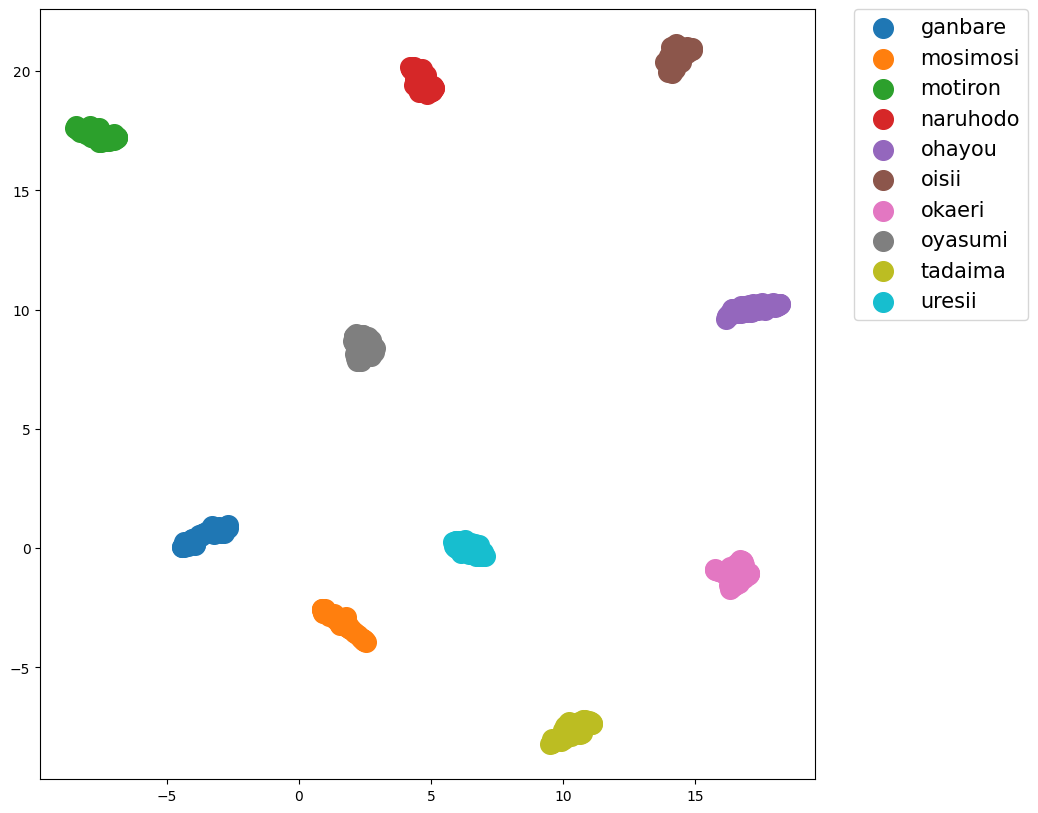

In [ ]:
#トレーニングデータ用のプログラム

min=0
max=6000
N=max-min
sf=4000

nperseg=256
noverlap=128
Sn=60

name=['ganbare','mosimosi','motiron','naruhodo','ohayou','oisii','okaeri','oyasumi','tadaima','uresii']


#UMAP設定--------------------------------------------------------------------------------------------
n_components=2
random_state=0
n_neighbors=15
min_dist=0.1
output_metric=['euclidean','cosine','manhattan']
output_metric=output_metric[0]

#グラフの設定--------------------------------------------------------------------------------------------
ma=['o']*10 #マーカーの種類
c = [
    '#1f77b4',  # 青
    '#ff7f0e',  # オレンジ
    '#2ca02c',  # 緑
    '#d62728',  # 赤
    '#9467bd',  # 紫
    '#8c564b',  # 茶色
    '#e377c2',  # ピンク
    '#7f7f7f',  # グレー
    '#bcbd22',  # イエロー
    '#17becf',   # シアン

    #'#7fffd4',  #アクアマリン
    #'#00ffff',  #アクア
    #'#13eac9',  #アクア2
    #'#ffd700',  #金
    #'#dbb40c',  #金2
]
#トレーニングデータ
path_trans='drive/MyDrive/suzuki_Data/suzuki/2024-11-06/emg2024-11-06-13-20-55/'
n_trans=50

target=[]
for i in range(len(name)):
    a=[i]*n_trans
    target=np.append(target,a)
target=target.reshape(len(target),1)

cou_trans=0
for name_num in range(len(name)):
    file_cou=0
    for file in glob.glob(path_trans+name[name_num]+'/*.csv'):
        cou_trans=cou_trans+1
        df=pd.read_csv(file,skiprows=13,header=None)
        data1=df[min:max][0]
        data2=df[min:max][1]
        data3=df[min:max][2]

        f1,t1,Sxx1=signal.spectrogram(data1,sf,nperseg=nperseg,noverlap=noverlap,window='hann')
        f2,t2,Sxx2=signal.spectrogram(data2,sf,nperseg=nperseg,noverlap=noverlap,window='hann')
        f3,t3,Sxx3=signal.spectrogram(data3,sf,nperseg=nperseg,noverlap=noverlap,window='hann')

        Sxx1,Sxx2,Sxx3=Sxx1[0:Sn],Sxx2[0:Sn],Sxx3[0:Sn]

        Sxx1=list(itertools.chain.from_iterable(Sxx1))
        Sxx2=list(itertools.chain.from_iterable(Sxx2))
        Sxx3=list(itertools.chain.from_iterable(Sxx3))

        if(cou_trans==1):
            Sxx1_all=Sxx1
            Sxx2_all=Sxx2
            Sxx3_all=Sxx3

            Sxx_all=np.concatenate([Sxx1,Sxx2,Sxx3])
            print(cou_trans,file)
        else:
            Sxx1_all=np.vstack([Sxx1_all,Sxx1])
            Sxx2_all=np.vstack([Sxx2_all,Sxx2])
            Sxx3_all=np.vstack([Sxx3_all,Sxx3])

            Sxx=np.concatenate([Sxx1,Sxx2,Sxx3])
            Sxx_all=np.vstack([Sxx_all,Sxx])
            print(cou_trans,file)
        file_cou=file_cou+1
        if file_cou==n_trans:
            break

#--------------------------------------------------------------------------------------------
cut_len_trans=Sn*len(t1)

final1=24*np.log(Sxx1_all)
final2=24*np.log(Sxx2_all)
final3=24*np.log(Sxx3_all)
final123=24*np.log(Sxx_all)

#UMAP
trans=umap.UMAP(n_components=n_components,random_state=random_state,n_neighbors=n_neighbors,min_dist=min_dist,output_metric=output_metric).fit(final123,y=target)

plt.figure(figsize=[10,10])
for i in range(len(name)):
  plt.scatter(trans.embedding_[n_trans*i:n_trans*(i+1),0],trans.embedding_[n_trans*i:n_trans*(i+1),1],c=c[i],s=200,marker=ma[i],label=name[i])
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0, fontsize=15)
# plt.title('UMAP(full-bond)'+' ch1~3'+'\n'+'STFT:  '+'nperseg='+str(nperseg)+'  '+'noverlap='+str(noverlap)+'  '+'Sn='+str(Sn)+'\n'+'UMAP:  '+'n_nei='+str(n_neighbors)+'  '+'min_dist='+str(min_dist),loc='left')
# plt.xlim(-20,40)
# plt.ylim(-20,30)
plt.show()
plt.clf()
plt.close()

/usr/local/lib/python3.10/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


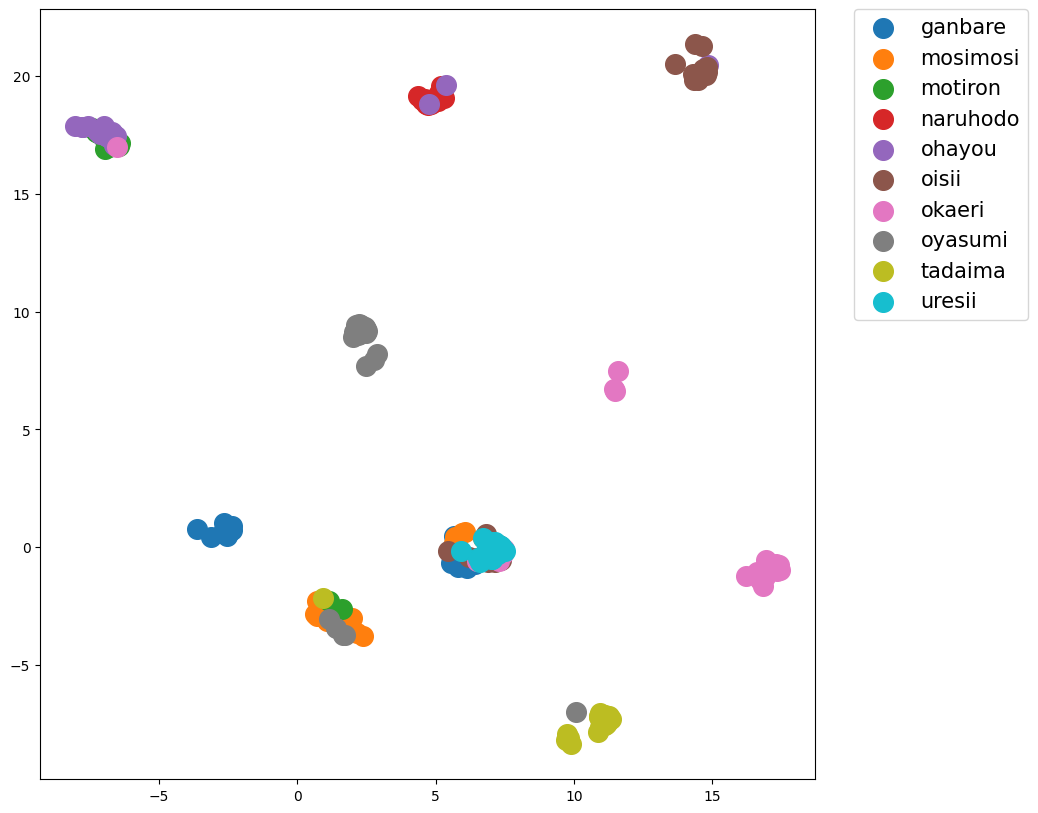

In [ ]:
#テストデータ
path_test='drive/MyDrive/suzuki_Data/suzuki/2024-12-16/emg2024-12-16-16-40-57/'
n_test=30

cou_test=0
for name_num in range(len(name)):
    file_cou=0
    for file in glob.glob(path_test+name[name_num]+'/*.csv'):
        cou_test=cou_test+1
        df=pd.read_csv(file,skiprows=13,header=None)
        data1_test=df[min:max][0]
        data2_test=df[min:max][1]
        data3_test=df[min:max][2]

        f1_test,t1_test,Sxx1_test=signal.spectrogram(data1_test,sf,nperseg=nperseg,noverlap=noverlap,window='hann')
        f2_test,t2_test,Sxx2_test=signal.spectrogram(data2_test,sf,nperseg=nperseg,noverlap=noverlap,window='hann')
        f3_test,t3_test,Sxx3_test=signal.spectrogram(data3_test,sf,nperseg=nperseg,noverlap=noverlap,window='hann')

        Sxx1_test,Sxx2_test,Sxx3_test=Sxx1_test[0:Sn],Sxx2_test[0:Sn],Sxx3_test[0:Sn]

        Sxx1_test=list(itertools.chain.from_iterable(Sxx1_test))
        Sxx2_test=list(itertools.chain.from_iterable(Sxx2_test))
        Sxx3_test=list(itertools.chain.from_iterable(Sxx3_test))

        if(cou_test==1):
            Sxx1_all_test=Sxx1_test
            Sxx2_all_test=Sxx2_test
            Sxx3_all_test=Sxx3_test

            Sxx_all_test=np.concatenate([Sxx1_test,Sxx2_test,Sxx3_test])
            # print(cou_test,file)
        else:
            Sxx1_all_test=np.vstack([Sxx1_all_test,Sxx1_test])
            Sxx2_all_test=np.vstack([Sxx2_all_test,Sxx2_test])
            Sxx3_all_test=np.vstack([Sxx3_all_test,Sxx3_test])

            Sxx_test=np.concatenate([Sxx1_test,Sxx2_test,Sxx3_test])
            Sxx_all_test=np.vstack([Sxx_all_test,Sxx_test])
            # print(cou_test,file)
        file_cou=file_cou+1
        if file_cou==n_test:
            break

#--------------------------------------------------------------------------------------------

final123_test=24*np.log(Sxx_all_test)

test_embedding=trans.transform(final123_test)

plt.figure(figsize=[10,10])
for i in range(len(name)):
  plt.scatter(test_embedding[n_test*i:n_test*(i+1),0],test_embedding[n_test*i:n_test*(i+1),1],c=c[i],s=200,marker=ma[i],label=name[i])
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0, fontsize=15)
# plt.title('UMAP(full-bond)'+' ch1~3'+'\n'+'STFT:  '+'nperseg='+str(nperseg)+'  '+'noverlap='+str(noverlap)+'  '+'Sn='+str(Sn)+'\n'+'UMAP:  '+'n_nei='+str(n_neighbors)+'  '+'min_dist='+str(min_dist),loc='left')
# plt.xlim(-20,40)
# plt.ylim(-20,30)
plt.show()
plt.clf()
plt.close()

/usr/local/lib/python3.10/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.10/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


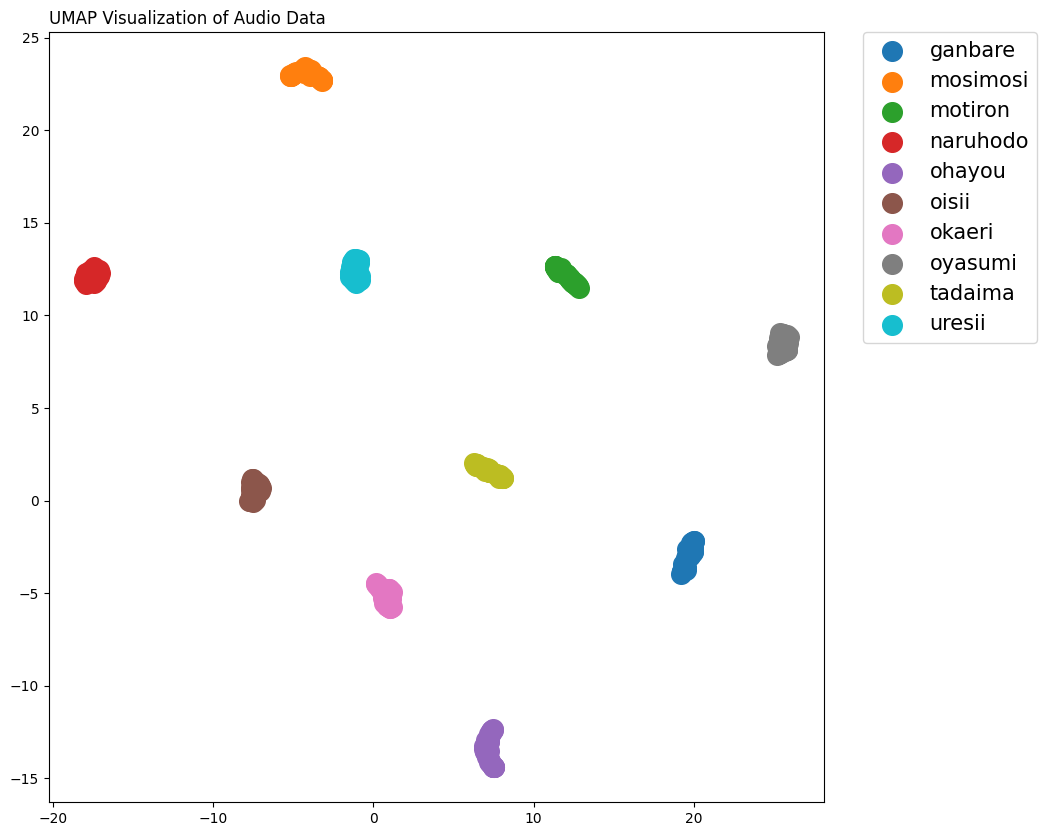

In [ ]:
import numpy as np
import pandas as pd
import glob
import itertools
from scipy import signal
import umap
import matplotlib.pyplot as plt

# パラメータ設定
min_idx = 0
max_idx = 6000
N = max_idx - min_idx
sf = 4000  # サンプリング周波数

nperseg = 256
noverlap = 128
Sn = 60

# 音声ラベルとクラス名
labels = ['ganbare', 'mosimosi', 'motiron', 'naruhodo', 'ohayou', 'oisii', 'okaeri', 'oyasumi', 'tadaima', 'uresii']
n_trans = 50

# UMAP設定
umap_params = {
    'n_components': 2,
    'random_state': 0,
    'n_neighbors': 15,
    'min_dist': 0.1,
    'metric': 'euclidean'
}

# プロット設定
markers = ['o'] * len(labels)
colors = [
    '#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd',
    '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf'
]

# データ読み込みパス
path_trans = 'drive/MyDrive/suzuki_Data/suzuki/2024-11-06/emg2024-11-06-13-20-55/'

# ターゲットラベル作成
target = np.concatenate([[i] * n_trans for i in range(len(labels))]).reshape(-1, 1)

# データ準備
Sxx_all = []
cou_trans = 0

for label_idx, label in enumerate(labels):
    file_count = 0
    for file in glob.glob(f"{path_trans}{label}/*.csv"):
        cou_trans += 1
        df = pd.read_csv(file, skiprows=13, header=None)

        # 各チャンネルデータの抽出
        data1, data2, data3 = df[min_idx:max_idx][0], df[min_idx:max_idx][1], df[min_idx:max_idx][2]

        # スペクトログラムの計算
        f1, t1, Sxx1 = signal.spectrogram(data1, sf, nperseg=nperseg, noverlap=noverlap, window='hann')
        f2, t2, Sxx2 = signal.spectrogram(data2, sf, nperseg=nperseg, noverlap=noverlap, window='hann')
        f3, t3, Sxx3 = signal.spectrogram(data3, sf, nperseg=nperseg, noverlap=noverlap, window='hann')

        # 必要な範囲に切り詰め
        Sxx1, Sxx2, Sxx3 = Sxx1[:Sn], Sxx2[:Sn], Sxx3[:Sn]

        # フラット化
        Sxx1 = list(itertools.chain.from_iterable(Sxx1))
        Sxx2 = list(itertools.chain.from_iterable(Sxx2))
        Sxx3 = list(itertools.chain.from_iterable(Sxx3))

        # 結合
        Sxx = np.concatenate([Sxx1, Sxx2, Sxx3])
        Sxx_all.append(Sxx)

        file_count += 1
        if file_count == n_trans:
            break

# 正規化と特徴量変換
Sxx_all = np.array(Sxx_all)
Sxx_all = 24 * np.log(Sxx_all + 1e-7)  # 安定性のために微小値を追加

# UMAP適用
umap_model = umap.UMAP(**umap_params)
embedding = umap_model.fit_transform(Sxx_all, y=target)

# プロット
plt.figure(figsize=(10, 10))
for i, label in enumerate(labels):
    plt.scatter(
        embedding[n_trans * i:n_trans * (i + 1), 0],
        embedding[n_trans * i:n_trans * (i + 1), 1],
        c=colors[i], s=200, marker=markers[i], label=label
    )

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0, fontsize=15)
plt.title('UMAP Visualization of Audio Data', loc='left')
plt.show()


In [ ]:
from sklearn.preprocessing import StandardScaler

#--------------------------------------------------------------------------------------------
#テストデータ
path_test='drive/MyDrive/suzuki_Data/suzuki/2024-12-16/emg2024-12-16-16-40-57/'
n_test=30

cou_test=0
for name_num in range(len(name)):
    file_cou=0
    for file in glob.glob(path_test+name[name_num]+'/*.csv'):
        cou_test=cou_test+1
        df=pd.read_csv(file,skiprows=13,header=None)
        data1_test=df[min:max][0]
        data2_test=df[min:max][1]
        data3_test=df[min:max][2]

        f1_test,t1_test,Sxx1_test=signal.spectrogram(data1_test,sf,nperseg=nperseg,noverlap=noverlap,window='hann')
        f2_test,t2_test,Sxx2_test=signal.spectrogram(data2_test,sf,nperseg=nperseg,noverlap=noverlap,window='hann')
        f3_test,t3_test,Sxx3_test=signal.spectrogram(data3_test,sf,nperseg=nperseg,noverlap=noverlap,window='hann')

        Sxx1_test,Sxx2_test,Sxx3_test=Sxx1_test[0:Sn],Sxx2_test[0:Sn],Sxx3_test[0:Sn]

        Sxx1_test=list(itertools.chain.from_iterable(Sxx1_test))
        Sxx2_test=list(itertools.chain.from_iterable(Sxx2_test))
        Sxx3_test=list(itertools.chain.from_iterable(Sxx3_test))

        if(cou_test==1):
            Sxx1_all_test=Sxx1_test
            Sxx2_all_test=Sxx2_test
            Sxx3_all_test=Sxx3_test

            Sxx_all_test=np.concatenate([Sxx1_test,Sxx2_test,Sxx3_test])
        else:
            Sxx1_all_test=np.vstack([Sxx1_all_test,Sxx1_test])
            Sxx2_all_test=np.vstack([Sxx2_all_test,Sxx2_test])
            Sxx3_all_test=np.vstack([Sxx3_all_test,Sxx3_test])

            Sxx_test=np.concatenate([Sxx1_test,Sxx2_test,Sxx3_test])
            Sxx_all_test=np.vstack([Sxx_all_test,Sxx_test])

        file_cou=file_cou+1
        if file_cou==n_test:
            break

#--------------------------------------------------------------------------------------------

# 標準化を追加
scaler = StandardScaler()
Sxx_all_test = scaler.fit_transform(Sxx_all_test)

final123_test = 24 * np.log(Sxx_all_test)

test_embedding = trans.transform(final123_test)

plt.figure(figsize=[10,10])
for i in range(len(name)):
    plt.scatter(test_embedding[n_test*i:n_test*(i+1), 0], test_embedding[n_test*i:n_test*(i+1), 1], c=c[i], s=200, marker=ma[i], label=name[i])
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0, fontsize=15)
# plt.title('UMAP(full-bond)'+' ch1~3'+'\n'+'STFT:  '+'nperseg='+str(nperseg)+'  '+'noverlap='+str(noverlap)+'  '+'Sn='+str(Sn)+'\n'+'UMAP:  '+'n_nei='+str(n_neighbors)+'  '+'min_dist='+str(min_dist),loc='left')
# plt.xlim(-20,40)
# plt.ylim(-20,30)
plt.show()
plt.clf()
plt.close()


<ipython-input-32-a7faf41140cc>:52: RuntimeWarning: invalid value encountered in log
  final123_test = 24 * np.log(Sxx_all_test)
/usr/local/lib/python3.10/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


ValueError: Input contains NaN.

In [ ]:
med_all=[]
for i in range(len(name)):
  med=np.median(trans.embedding_[n_trans*i:n_trans*(i+1)],axis=0)
  if i==0:
    med_all=med
  else:
    med_all=np.vstack([med_all,med])
print(med_all)

[[  9.942598    14.104472  ]
 [ 18.641088     5.1094437 ]
 [ -4.8159647   22.566908  ]
 [  1.7294807    8.610092  ]
 [ -0.39924315  -4.3386307 ]
 [ 30.86102     10.648764  ]
 [ 16.331726    -7.9281645 ]
 [ -0.03605964   3.309363  ]
 [ 16.545395   -18.53397   ]
 [ 21.667294    22.296837  ]]


In [ ]:
#正誤判定
correct_n=0
per=0
per_single=0

print(name[correct_n])
for test in range(len(test_embedding)):
    distance=100

    for n in range(len(name)):
        dis_cal=np.linalg.norm(med_all[n]-test_embedding[test])
        if distance>dis_cal:
            distance=dis_cal
            result=n

    distance_correct=np.linalg.norm(med_all[correct_n]-test_embedding[test])



    if correct_n==result:
        per=per+1
        per_single=per_single+1
        print("正",result,distance)
    else:
        print('誤',result,distance,distance_correct)

    if (test+1)%n_test==0:
        correct_n+=1
        print(per_single*100/n_test)
        per_single=0
        if(correct_n<len(name)):
            print('************************************************************')
            print(name[correct_n])
print('************************************************************')
print('all=',per*100/len(test_embedding))

ganbare
誤 6 5.9478617 19.686144
誤 6 6.8191648 19.06607
誤 6 6.6950264 19.216433
誤 1 7.0355086 15.51971
誤 3 5.2056274 10.710101
誤 6 6.769524 18.931604
誤 7 8.151853 10.898682
誤 3 5.5410495 10.96119
誤 3 4.0203137 11.607604
誤 6 6.475835 18.929695
誤 2 0.9121187 16.25158
誤 3 2.093711 11.413457
誤 6 6.741421 18.85991
誤 3 5.1232834 10.545279
誤 3 4.7811146 10.656496
誤 3 5.188685 10.251033
誤 3 5.0205 10.486297
誤 3 5.1380544 10.714446
誤 3 5.2892036 10.582939
誤 6 6.9558506 18.823463
誤 3 4.770927 10.624756
誤 6 6.5713744 18.56688
誤 3 4.8311915 10.674192
誤 3 4.7923536 10.620438
誤 3 4.8946323 10.706285
誤 3 5.242795 10.789212
誤 3 4.6802373 10.584062
誤 3 5.153265 10.8383665
誤 3 5.400121 10.72781
誤 3 4.6859016 10.560865
0.0
************************************************************
mosimosi
誤 2 1.6075041 27.903353
誤 2 1.5988165 28.338697
誤 2 1.6433326 28.265137
誤 2 1.7886174 27.792898
誤 2 1.426122 28.468243
誤 2 1.3012195 29.078808
誤 2 1.0407677 29.710365
誤 2 1.4706277 28.107397
誤 3 5.7404475 21.790789
誤 

# 認識実験（同じフォルダ）

In [ ]:
min=0
max=6000
N=max-min
sf=4000

#nperseg=256
#noverlap=128

nperseg=128
noverlap=64
#179,205,230
Sn=60

name= ['ame', 'asa', 'ie', 'inu', 'kame', 'kasa', 'kumo', 'kutu', 'suna', 'usi', 'ohayou', 'tadaima', 'okaeri', 'oyasumi', 'ganbare', 'motiron', 'naruhodo', 'uresii', 'oisii', 'mosimosi']

In [ ]:
#トレーニングデータ
path='drive/MyDrive/suzuki_Data/suzuki/2345文字コマンド/'
n_all=30
n_test=10
n_trans=n_all-n_test

target=[]
for i in range(len(name)):
    a=[i]*n_trans
    target=np.append(target,a)
target=target.reshape(len(target),1)

cou_trans = 0
for name_num in range(len(name)):
    file_cou = 0
    for file in glob.glob(path + name[name_num] + '/*.csv'):
        cou_trans = cou_trans + 1
        df = pd.read_csv(file, skiprows=13, header=None)

        # データの切り出し（min:maxが定義されている前提）
        data1 = df[min:max][0]
        data2 = df[min:max][1]
        data3 = df[min:max][2]

        f1, t1, Sxx1 = signal.spectrogram(data1, sf, nperseg=nperseg, noverlap=noverlap, window='hamming')
        f2, t2, Sxx2 = signal.spectrogram(data2, sf, nperseg=nperseg, noverlap=noverlap, window='hamming')
        f3, t3, Sxx3 = signal.spectrogram(data3, sf, nperseg=nperseg, noverlap=noverlap, window='hamming')

        Sxx1, Sxx2, Sxx3 = Sxx1[0:Sn], Sxx2[0:Sn], Sxx3[0:Sn]

        # リスト化（ここで長さが変わる可能性がある）
        Sxx1 = list(itertools.chain.from_iterable(Sxx1))
        Sxx2 = list(itertools.chain.from_iterable(Sxx2))
        Sxx3 = list(itertools.chain.from_iterable(Sxx3))
        Sxx = np.concatenate([Sxx1, Sxx2, Sxx3]) # 1ファイル分の結合データ

        if cou_trans == 1:
            # 初回はそのまま代入（1次元配列を2次元に変換しておく）
            Sxx1_all = np.array([Sxx1])
            Sxx2_all = np.array([Sxx2])
            Sxx3_all = np.array([Sxx3])
            Sxx_all = np.array([Sxx])
            print(cou_trans, file)
        else:
            # 内側で定義する関数の max() を np.maximum() に変更
            def pad_to_match(all_data, new_data):
                # all_data.shape[1] と len(new_data) の大きい方を取得
                # 組み込みの max() が変数で上書きされていても np.maximum なら動きます
                current_all_len = all_data.shape[1]
                current_new_len = len(new_data)
                target_len = int(np.maximum(current_all_len, current_new_len))

                # 蓄積済みデータが短い場合、右側を0埋め
                if current_all_len < target_len:
                    all_data = np.pad(all_data, ((0, 0), (0, target_len - current_all_len)), mode='constant')

                # 新しいデータが短い場合、右側を0埋め
                new_data_padded = np.pad(new_data, (0, target_len - current_new_len), mode='constant')

                return all_data, new_data_padded

            # 各データをパディングして結合
            Sxx1_all, Sxx1_p = pad_to_match(Sxx1_all, Sxx1)
            Sxx2_all, Sxx2_p = pad_to_match(Sxx2_all, Sxx2)
            Sxx3_all, Sxx3_p = pad_to_match(Sxx3_all, Sxx3)
            Sxx_all, Sxx_p = pad_to_match(Sxx_all, Sxx)

            Sxx1_all = np.vstack([Sxx1_all, Sxx1_p])
            Sxx2_all = np.vstack([Sxx2_all, Sxx2_p])
            Sxx3_all = np.vstack([Sxx3_all, Sxx3_p])
            Sxx_all = np.vstack([Sxx_all, Sxx_p])

            print(cou_trans, file)

        file_cou = file_cou + 1
        if file_cou == n_all:
            break

#--------------------------------------------------------------------------------------------
Sxx1_all = np.where(Sxx1_all == 0, 1e-10, Sxx1_all)
Sxx2_all = np.where(Sxx2_all == 0, 1e-10, Sxx2_all)
Sxx3_all = np.where(Sxx3_all == 0, 1e-10, Sxx3_all)
Sxx_all = np.where(Sxx_all == 0, 1e-10, Sxx_all)
final1=24*np.log(Sxx1_all)
final2=24*np.log(Sxx2_all)
final3=24*np.log(Sxx3_all)
final123=24*np.log(Sxx_all)

for cut_n in range(len(name)):
    if(cut_n==0):
        final_trans=final123[n_all*cut_n:n_all*(cut_n+1)-n_test]
    else:
        final_trans=np.vstack([final_trans,final123[n_all*cut_n:n_all*(cut_n+1)-n_test]])


for cut_n in range(len(name)):
    if(cut_n==0):
        final_test=final123[n_all*cut_n+n_trans:n_all*(cut_n+1)]
    else:
        final_test=np.vstack([final_test,final123[n_all*cut_n+n_trans:n_all*(cut_n+1)]])
# **最終的な行列の形状**
print("最終的な行列の形状:", final123.shape)

1 drive/MyDrive/suzuki_Data/suzuki/2345文字コマンド/ame/ameEMG2024-11-20-14-57-37.csv
2 drive/MyDrive/suzuki_Data/suzuki/2345文字コマンド/ame/ameEMG2024-11-20-14-57-41.csv
3 drive/MyDrive/suzuki_Data/suzuki/2345文字コマンド/ame/ameEMG2024-11-20-14-57-44.csv
4 drive/MyDrive/suzuki_Data/suzuki/2345文字コマンド/ame/ameEMG2024-11-20-14-57-47.csv
5 drive/MyDrive/suzuki_Data/suzuki/2345文字コマンド/ame/ameEMG2024-11-20-14-57-49.csv
6 drive/MyDrive/suzuki_Data/suzuki/2345文字コマンド/ame/ameEMG2024-11-20-14-57-52.csv
7 drive/MyDrive/suzuki_Data/suzuki/2345文字コマンド/ame/ameEMG2024-11-20-14-57-55.csv
8 drive/MyDrive/suzuki_Data/suzuki/2345文字コマンド/ame/ameEMG2024-11-20-14-57-58.csv
9 drive/MyDrive/suzuki_Data/suzuki/2345文字コマンド/ame/ameEMG2024-11-20-14-58-01.csv
10 drive/MyDrive/suzuki_Data/suzuki/2345文字コマンド/ame/ameEMG2024-11-20-14-58-03.csv
11 drive/MyDrive/suzuki_Data/suzuki/2345文字コマンド/ame/ameEMG2024-11-20-14-58-06.csv
12 drive/MyDrive/suzuki_Data/suzuki/2345文字コマンド/ame/ameEMG2024-11-20-14-58-09.csv
13 drive/MyDrive/suzuki_D

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


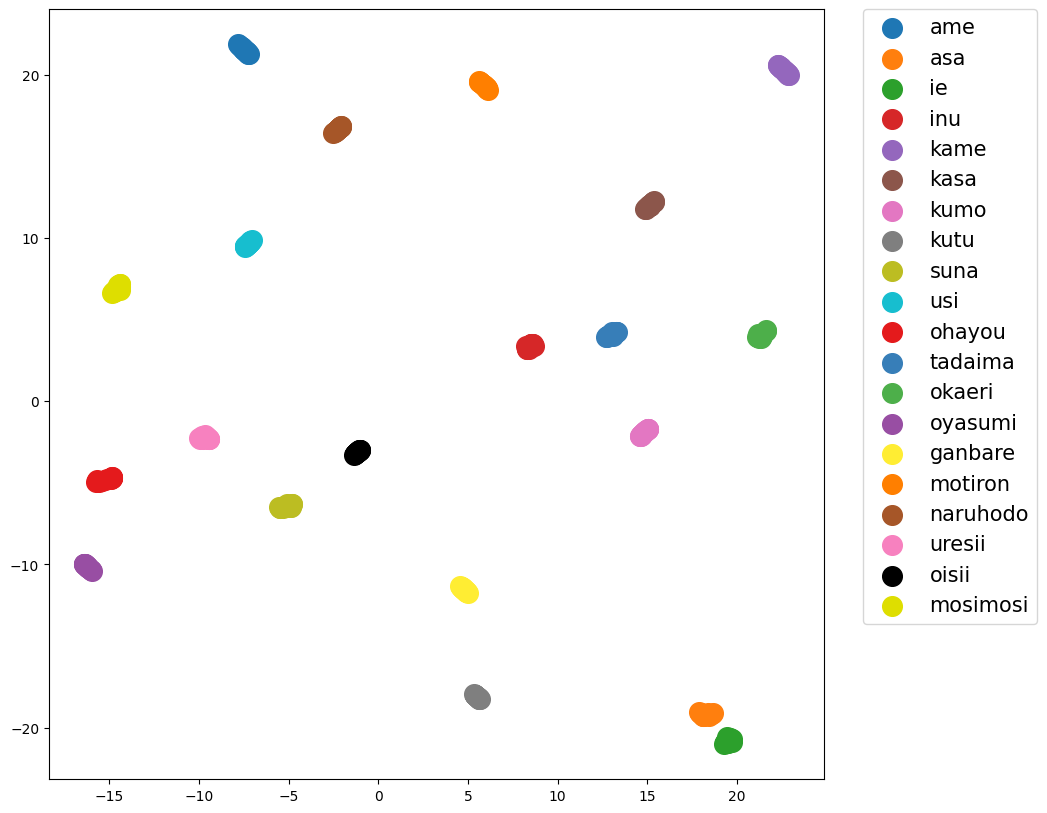

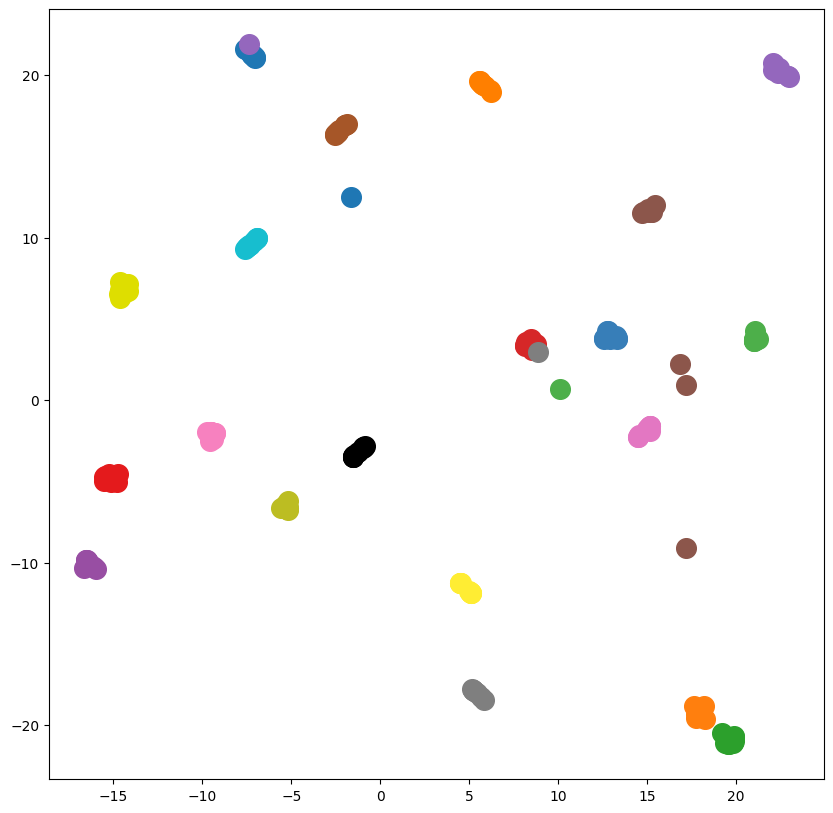

In [ ]:
#UMAP設定--------------------------------------------------------------------------------------------
n_components=2
random_state=0
n_neighbors=15
min_dist=0.1
output_metric=['euclidean','cosine','manhattan']
output_metric=output_metric[0]

#グラフの設定--------------------------------------------------------------------------------------------
ma=['o']*20 #マーカーの種類
c = [
    '#1f77b4',  # 青
    '#ff7f0e',  # オレンジ
    '#2ca02c',  # 緑
    '#d62728',  # 赤
    '#9467bd',  # 紫
    '#8c564b',  # 茶色
    '#e377c2',  # ピンク
    '#7f7f7f',  # グレー
    '#bcbd22',  # イエロー
    '#17becf',   # シアン

    '#e41a1c',  # 青
    '#377eb8',  # オレンジ
    '#4daf4a',  # 緑
    '#984ea3',  # 赤
    '#ffed33',  # 紫
    '#ff7f00',  # 茶色
    '#a65628',  # ピンク
    '#f781bf',  # グレー
    '#000000',  # イエロー
    '#dede00',   # シアン

    #'#7fffd4',  #アクアマリン
    #'#00ffff',  #アクア
    #'#13eac9',  #アクア2
    #'#ffd700',  #金
    #'#dbb40c',  #金2
]



#UMAP
#トレーニングデータ
trans=umap.UMAP(n_components=n_components,n_neighbors=n_neighbors,random_state=random_state,min_dist=min_dist,output_metric=output_metric).fit(final_trans,y=target)

plt.figure(figsize=[10,10])
for i in range(len(name)):
  plt.scatter(trans.embedding_[n_trans*i:n_trans*(i+1),0],trans.embedding_[n_trans*i:n_trans*(i+1),1],c=c[i],s=200,marker=ma[i],label=name[i])
  # for text_num in range(n_trans*i,n_trans*(i+1)):
  #   plt.text(trans.embedding_[text_num,0],trans.embedding_[text_num,1],"{}".format(text_num))
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0, fontsize=15)
#plt.title('UMAP(full-bond)'+' ch1~3'+'\n'+'STFT:  '+'nperseg='+str(nperseg)+'  '+'noverlap='+str(noverlap)+'  '+'Sn='+str(Sn)+'\n'+'UMAP:  '+'n_nei='+str(n_neighbors)+'  '+'min_dist='+str(min_dist),loc='left')
#plt.xlim(-10,20)
#plt.ylim(-5,8)
plt.show()
plt.clf()
plt.close()


#テストデータ
test_embedding=trans.transform(final_test)

plt.figure(figsize=[10,10])
for i in range(len(name)):
  plt.scatter(test_embedding[n_test*i:n_test*(i+1),0],test_embedding[n_test*i:n_test*(i+1),1],c=c[i],s=200,marker=ma[i],label=name[i])
  # for text_num in range(n_test*i,n_test*(i+1)):
  #   plt.text(test_embedding[text_num,0],test_embedding[text_num,1],"{}".format(text_num))
# plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0, fontsize=15)
# plt.title('UMAP(full-bond)'+' ch1~3'+'\n'+'STFT:  '+'nperseg='+str(nperseg)+'  '+'noverlap='+str(noverlap)+'  '+'Sn='+str(Sn)+'\n'+'UMAP:  '+'n_nei='+str(n_neighbors)+'  '+'min_dist='+str(min_dist),loc='left')
# plt.xlim(-10,20)
# plt.ylim(-5,8)
plt.show()
plt.clf()
plt.close()

In [ ]:
med_all=[]
for i in range(len(name)):
  med=np.median(trans.embedding_[n_trans*i:n_trans*(i+1)],axis=0)
  if i==0:
    med_all=med
  else:
    med_all=np.vstack([med_all,med])
print(med_all)

[[ -7.447657   21.487873 ]
 [ 18.137447  -19.180529 ]
 [ 19.520473  -20.849487 ]
 [  8.434206    3.3521168]
 [ 22.62284    20.220158 ]
 [ 15.123213   11.9866905]
 [ 14.794907   -1.9359136]
 [  5.4505205 -18.064064 ]
 [ -5.101413   -6.447036 ]
 [ -7.26425     9.639814 ]
 [-15.328196   -4.844188 ]
 [ 13.033447    4.087967 ]
 [ 21.279507    4.002057 ]
 [-16.245968  -10.11834  ]
 [  4.7412996 -11.509108 ]
 [  5.865227   19.33371  ]
 [ -2.2242649  16.68279  ]
 [ -9.636502   -2.2545412]
 [ -1.196089   -3.1399734]
 [-14.486456    6.9002275]]


In [ ]:
#正誤判定
correct_n=0
per=0
per_single=0

print(name[correct_n])
for test in range(len(test_embedding)):
    distance=100

    for n in range(len(name)):
        dis_cal=np.linalg.norm(med_all[n]-test_embedding[test])
        if distance>dis_cal:
            distance=dis_cal
            result=n

    distance_correct=np.linalg.norm(med_all[correct_n]-test_embedding[test])



    if correct_n==result:
        per=per+1
        per_single=per_single+1
        print("正",result,distance)
    else:
        print('誤',result,distance,distance_correct)

    if (test+1)%n_test==0:
        correct_n+=1
        print(per_single*100/n_test)
        per_single=0
        if(correct_n<len(name)):
            print('************************************************************')
            print(name[correct_n])
print('************************************************************')
print('all=',per*100/len(test_embedding))

ame
正 0 0.58693945
正 0 0.28479704
正 0 0.17610604
正 0 0.3353129
正 0 0.19591688
誤 16 4.2094584 10.683487
正 0 0.49505082
正 0 0.5342759
正 0 0.35200825
正 0 0.39788014
90.0
************************************************************
asa
正 1 0.63592076
正 1 0.21312357
正 1 0.43803316
正 1 0.52759737
正 1 0.4059694
正 1 0.10518499
正 1 0.4282403
正 1 0.3503203
正 1 0.3713964
正 1 0.37131348
100.0
************************************************************
ie
正 2 0.47721285
正 2 0.33008718
正 2 0.3756373
正 2 0.30383587
正 2 0.29793674
正 2 0.33682418
正 2 0.39169058
正 2 0.2803101
正 2 0.37459788
正 2 0.43288705
100.0
************************************************************
inu
正 3 0.37102672
正 3 0.30573848
正 3 0.33281377
正 3 0.44014013
正 3 0.34646404
正 3 0.28773895
正 3 0.30247164
正 3 0.27499467
正 3 0.1541875
正 3 0.20369944
100.0
************************************************************
kame
誤 0 0.41277587 30.056864
正 4 0.7214479
正 4 0.42385373
正 4 0.5512974
正 4 0.2931547
正 4 0.49168625
正 4 0.28838894
